# Transform Pipeline: From Raw Data to Kriging Input

Sequential data transformations applied before kriging interpolation.
All transforms use production classes from `thesis.transforms`.

In [1]:
import sys, os
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew

import warnings
warnings.filterwarnings("ignore")

print(f"Working directory: {os.getcwd()}")

Working directory: /Users/etomengoi/Desktop/precip_interpolation_thesis


## Pipeline Overview

```
Raw station data (mm)
    ↓
[1] ProjectionTransform   — lon/lat → EPSG:3035 (metres)
    ↓
[2] IndicatorTransform    — wet/dry classification (threshold 0.5 mm)
    ↓
[3] DetrendTransform      — quota = daily_mm / monthly_normal
    ↓
[4a] NormalScoreTransform — Gaussian ranks (Cecinati 2017)
[4b] LogTransform         — log(quota + offset)
[4c] No transform         — raw quota
    ↓
Ready for kriging
```

Steps [1-3] are **mandatory**. Step [4] is chosen per experiment.

## Load Data and Fit Pipeline (Full Period)

Monthly normals and the normal-score CDF must be computed from the **entire** historical record (1961-2023), not a single day. This ensures:
- `DetrendTransform` learns stable per-station monthly totals across decades
- `NormalScoreTransform` builds the empirical CDF from millions of wet-day quotas

In [2]:
from thesis.config import Config
from thesis.data.registry import DataRegistry
from thesis.transforms import (
    ProjectionTransform, IndicatorTransform,
    DetrendTransform, NormalScoreTransform, LogTransform,
)

cfg = Config()
registry = DataRegistry.from_config(cfg)

# Load the full historical record for proper pipeline fitting
print(f"Loading ReKIS data ({cfg.date_start} to {cfg.date_end})...")
all_raw = registry.stations.load(cfg.date_start, cfg.date_end)
print(f"Loaded {len(all_raw):,} rows, {all_raw['station_id'].nunique()} stations")

# Instantiate transforms with production parameters
proj = ProjectionTransform(target_crs=cfg.study_area.target_crs)
ind  = IndicatorTransform(threshold_mm=cfg.wet_day_threshold_mm)
det  = DetrendTransform()
ns   = NormalScoreTransform()
log_t = LogTransform(offset=cfg.log_transform_offset)

# Fit and apply sequentially (same order as production pipeline)
print("\nFitting pipeline on full period...")
proj.fit(all_raw);   df_proj = proj.apply(all_raw)
ind.fit(df_proj);    df_ind  = ind.apply(df_proj)
det.fit(df_ind);     df_det  = det.apply(df_ind)
ns.fit(df_det);      df_ns   = ns.apply(df_det)
log_t.fit(df_det);   df_log  = log_t.apply(df_det)

print(f"Pipeline fitted.")
print(f"  DetrendTransform: {len(det._monthly_totals):,} (station, month) normals")
print(f"  NormalScoreTransform: {len(ns._sorted_vals):,} wet-day quotas in CDF")

Loading ReKIS data (1961-01-01 to 2023-12-31)...
Loaded 56,558,580 rows, 2458 stations

Fitting pipeline on full period...
Pipeline fitted.
  DetrendTransform: 29,496 (station, month) normals
  NormalScoreTransform: 21,745,253 wet-day quotas in CDF


## Select One Day for Visualization

In [3]:
# Pick a day with a good wet/dry mix (30-70% wet) for informative visualization
wet_frac = df_ind.groupby("date")["rain_indicator"].mean()
candidates = wet_frac[(wet_frac > 0.3) & (wet_frac < 0.7)].index
DATE = str(np.random.RandomState(42).choice(candidates))

raw_day = all_raw[all_raw["date"] == DATE].copy()
n_dry = int((raw_day["precip_mm"] < cfg.wet_day_threshold_mm).sum())
print(f"Date: {DATE}")
print(f"Stations: {len(raw_day)}, dry: {n_dry}, wet: {len(raw_day) - n_dry}")
print(f"Precip range: {raw_day['precip_mm'].min():.1f} – {raw_day['precip_mm'].max():.1f} mm")
print(f"Mean (all): {raw_day['precip_mm'].mean():.2f} mm")
print(f"Mean (wet): {raw_day.loc[raw_day['precip_mm'] >= cfg.wet_day_threshold_mm, 'precip_mm'].mean():.2f} mm")

Date: 1970-04-04
Stations: 2458, dry: 880, wet: 1578
Precip range: 0.0 – 18.5 mm
Mean (all): 1.58 mm
Mean (wet): 2.41 mm


## Step 1: Projection (WGS84 to EPSG:3035)

Kriging requires planar coordinates for isotropic distance calculations.
`ProjectionTransform` converts geographic lon/lat to ETRS89-LAEA metres.

In [4]:
day_proj = proj.apply(raw_day)

print(f"ProjectionTransform: WGS84 → {cfg.study_area.target_crs}")
print(f"  lon  [{day_proj['lon'].min():.2f}, {day_proj['lon'].max():.2f}]°")
print(f"  lat  [{day_proj['lat'].min():.2f}, {day_proj['lat'].max():.2f}]°")
print(f"  x    [{day_proj['x_proj'].min()/1e6:.3f}, {day_proj['x_proj'].max()/1e6:.3f}] Mm")
print(f"  y    [{day_proj['y_proj'].min()/1e6:.3f}, {day_proj['y_proj'].max()/1e6:.3f}] Mm")
print(f"\n  Precipitation data: unchanged")

ProjectionTransform: WGS84 → EPSG:3035
  lon  [9.53, 15.82]°
  lat  [50.08, 53.71]°
  x    [4.290, 4.714] Mm
  y    [3.001, 3.409] Mm

  Precipitation data: unchanged


## Step 2: Indicator (Wet/Dry Classification)

Two-stage kriging separates P(rain) from E[amount | rain].
`IndicatorTransform` adds `rain_indicator` (1 = wet, 0 = dry) using a threshold of 0.5 mm (Haylock 2008).

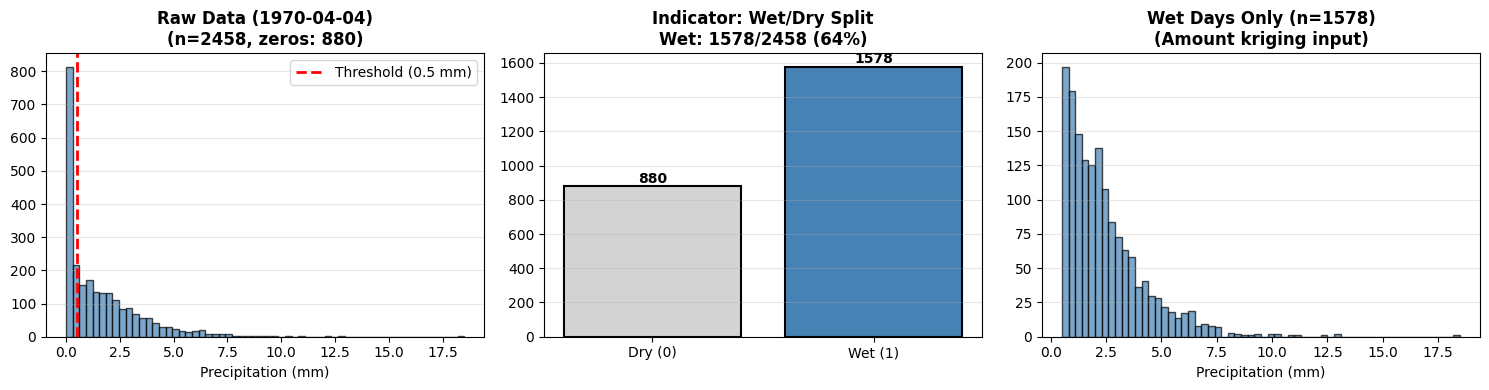

IndicatorTransform: threshold = 0.5 mm
  Dry: 880  |  Wet: 1,578
  Wet-day mean: 2.41 mm, max: 18.5 mm


In [5]:
day_ind = ind.apply(day_proj)

precip_mm = day_ind["precip_mm"].values
rain_indicator = day_ind["rain_indicator"].values
wet_precip = precip_mm[rain_indicator == 1]
n_wet = int(rain_indicator.sum())
n_dry = n_total = len(precip_mm)
n_dry = n_total - n_wet

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(precip_mm, bins=60, color="steelblue", edgecolor="black", alpha=0.7)
axes[0].axvline(cfg.wet_day_threshold_mm, color="red", linestyle="--", linewidth=2,
                label=f"Threshold ({cfg.wet_day_threshold_mm} mm)")
axes[0].set_xlabel("Precipitation (mm)")
axes[0].set_title(f"Raw Data ({DATE})\n(n={n_total}, zeros: {n_dry})", fontweight="bold")
axes[0].legend()
axes[0].grid(alpha=0.3, axis="y")

ind_counts = [n_dry, n_wet]
axes[1].bar(["Dry (0)", "Wet (1)"], ind_counts, color=["lightgray", "steelblue"],
            edgecolor="black", linewidth=1.5)
axes[1].set_title(f"Indicator: Wet/Dry Split\nWet: {n_wet}/{n_total} ({n_wet/n_total:.0%})", fontweight="bold")
axes[1].grid(alpha=0.3, axis="y")
for i, v in enumerate(ind_counts):
    axes[1].text(i, v + 20, str(v), ha="center", fontweight="bold")

axes[2].hist(wet_precip, bins=60, color="steelblue", edgecolor="black", alpha=0.7)
axes[2].set_xlabel("Precipitation (mm)")
axes[2].set_title(f"Wet Days Only (n={n_wet})\n(Amount kriging input)", fontweight="bold")
axes[2].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print(f"IndicatorTransform: threshold = {cfg.wet_day_threshold_mm} mm")
print(f"  Dry: {n_dry:,}  |  Wet: {n_wet:,}")
print(f"  Wet-day mean: {wet_precip.mean():.2f} mm, max: {wet_precip.max():.1f} mm")

## Step 3: Detrending (Monthly Normalization)

Remove seasonal trend by dividing by monthly climatology (Haylock et al. 2008):

$$q_i = \frac{x_i}{N_{s,m}}$$

where $N_{s,m}$ is the mean monthly total for station $s$ in month $m$, learned from the **entire** 1961-2023 record by `DetrendTransform`.

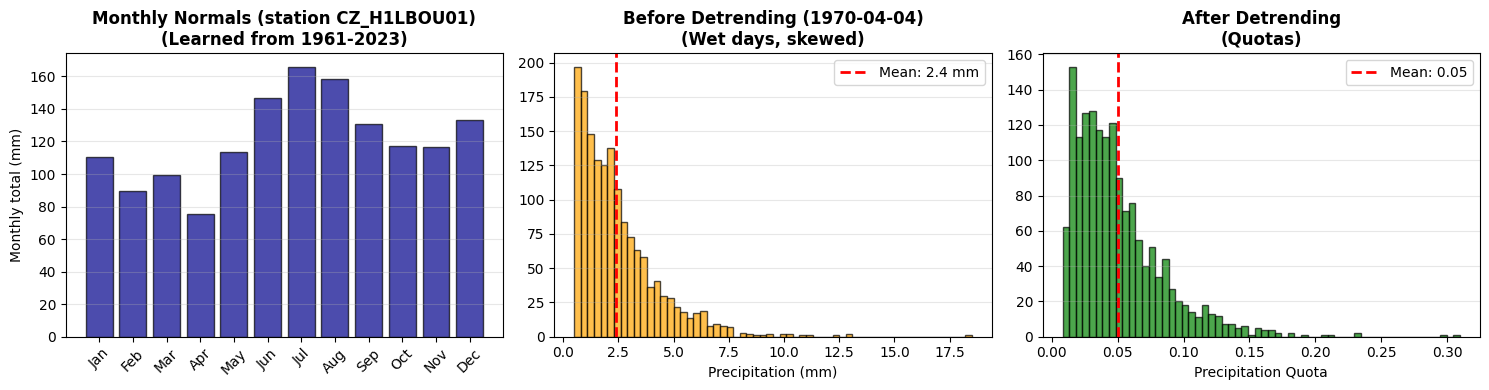

DetrendTransform: quota = daily_mm / monthly_normal
  Wet amounts  — mean: 2.41 mm, std: 1.79 mm
  Quotas       — mean: 0.050,     std: 0.034
  Grand mean monthly normal: 55.8 mm


In [6]:
day_det = det.apply(day_ind)

quota = day_det.loc[day_det["rain_indicator"] == 1, "precip_quota"].values

# Show monthly normals for a sample station
sample_sid = day_det["station_id"].iloc[0]
sample_norms = det._monthly_totals.xs(sample_sid, level="station_id")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Monthly normals for one station
months_label = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
axes[0].bar(months_label, sample_norms.values, color="darkblue", alpha=0.7, edgecolor="black")
axes[0].set_ylabel("Monthly total (mm)")
axes[0].set_title(f"Monthly Normals (station {sample_sid})\n(Learned from 1961-2023)", fontweight="bold")
axes[0].set_xticks(range(12))
axes[0].set_xticklabels(months_label, rotation=45)
axes[0].grid(alpha=0.3, axis="y")

# Before: wet amounts
axes[1].hist(wet_precip, bins=60, color="orange", edgecolor="black", alpha=0.7)
axes[1].axvline(wet_precip.mean(), color="red", linestyle="--", linewidth=2,
                label=f"Mean: {wet_precip.mean():.1f} mm")
axes[1].set_xlabel("Precipitation (mm)")
axes[1].set_title(f"Before Detrending ({DATE})\n(Wet days, skewed)", fontweight="bold")
axes[1].legend()
axes[1].grid(alpha=0.3, axis="y")

# After: quotas
axes[2].hist(quota, bins=60, color="green", edgecolor="black", alpha=0.7)
axes[2].axvline(quota.mean(), color="red", linestyle="--", linewidth=2,
                label=f"Mean: {quota.mean():.2f}")
axes[2].set_xlabel("Precipitation Quota")
axes[2].set_title("After Detrending\n(Quotas)", fontweight="bold")
axes[2].legend()
axes[2].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print(f"DetrendTransform: quota = daily_mm / monthly_normal")
print(f"  Wet amounts  — mean: {wet_precip.mean():.2f} mm, std: {wet_precip.std():.2f} mm")
print(f"  Quotas       — mean: {quota.mean():.3f},     std: {quota.std():.3f}")
print(f"  Grand mean monthly normal: {float(det._monthly_totals.mean()):.1f} mm")

## Step 4a: Normal-Score Transform

Maps wet-day quotas to N(0,1) via empirical CDF + probit (Cecinati et al. 2017):

$$z_i = \Phi^{-1}\left(\frac{\text{rank}(q_i)}{N+1}\right)$$

`NormalScoreTransform` uses Blom plotting positions and a CDF built from all wet-day quotas across 1961-2023.

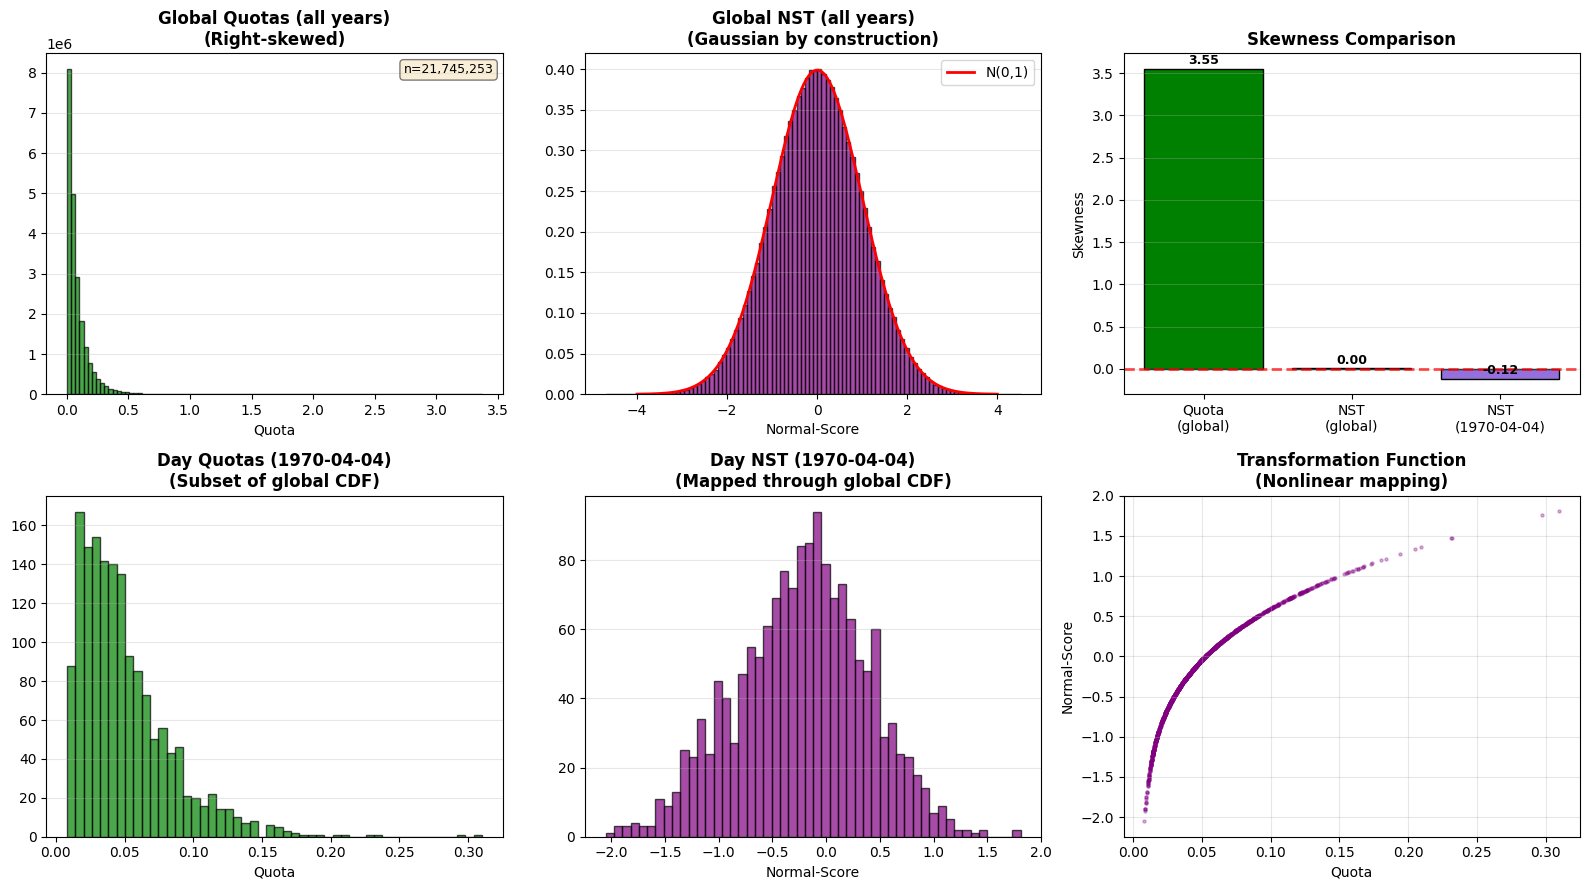

NormalScoreTransform (CDF from 21,745,253 training values):
  Global skewness: quota=3.554 → NST=0.004
  Per-day skewness (1970-04-04): quota=1.840 → NST=-0.117
  (Per-day is a subset of global CDF — not guaranteed Gaussian)


In [7]:
day_ns = ns.apply(day_det)
nst_scores = day_ns.loc[day_ns["rain_indicator"] == 1, "precip_normal_score"].values

# Global NST: all 21M wet-day quotas → Gaussian by construction
global_nst = df_ns.loc[df_ns["rain_indicator"] == 1, "precip_normal_score"].values
# Subsample for fast plotting
rng = np.random.RandomState(42)
global_nst_sample = rng.choice(global_nst, size=500_000, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Row 1: Global NST (proves the transform works)
axes[0, 0].hist(ns._sorted_vals, bins=100, color="green", edgecolor="black", alpha=0.7)
axes[0, 0].set_xlabel("Quota")
axes[0, 0].set_title("Global Quotas (all years)\n(Right-skewed)", fontweight="bold")
axes[0, 0].grid(alpha=0.3, axis="y")
axes[0, 0].text(0.98, 0.97, f"n={len(ns._sorted_vals):,}", transform=axes[0, 0].transAxes,
                ha="right", va="top", fontsize=9,
                bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

from scipy.stats import norm
axes[0, 1].hist(global_nst_sample, bins=100, color="purple", edgecolor="black", alpha=0.7, density=True)
x_ref = np.linspace(-4, 4, 200)
axes[0, 1].plot(x_ref, norm.pdf(x_ref), "r-", linewidth=2, label="N(0,1)")
axes[0, 1].set_xlabel("Normal-Score")
axes[0, 1].set_title("Global NST (all years)\n(Gaussian by construction)", fontweight="bold")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3, axis="y")

# Skewness: global vs per-day
skew_quota_global = skew(rng.choice(ns._sorted_vals, 500_000, replace=False))
skew_nst_global = skew(global_nst_sample)
skew_nst_day = skew(nst_scores)
bars = axes[0, 2].bar(["Quota\n(global)", "NST\n(global)", f"NST\n({DATE})"],
                       [skew_quota_global, skew_nst_global, skew_nst_day],
                       color=["green", "purple", "mediumpurple"], edgecolor="black")
axes[0, 2].axhline(0, color="red", linestyle="--", linewidth=2, alpha=0.7)
axes[0, 2].set_ylabel("Skewness")
axes[0, 2].set_title("Skewness Comparison", fontweight="bold")
axes[0, 2].grid(alpha=0.3, axis="y")
for bar, v in zip(bars, [skew_quota_global, skew_nst_global, skew_nst_day]):
    axes[0, 2].text(bar.get_x() + bar.get_width()/2, v + 0.05, f"{v:.2f}",
                    ha="center", fontweight="bold", fontsize=9)

# Row 2: Per-day view
axes[1, 0].hist(quota, bins=50, color="green", edgecolor="black", alpha=0.7)
axes[1, 0].set_xlabel("Quota")
axes[1, 0].set_title(f"Day Quotas ({DATE})\n(Subset of global CDF)", fontweight="bold")
axes[1, 0].grid(alpha=0.3, axis="y")

axes[1, 1].hist(nst_scores, bins=50, color="purple", edgecolor="black", alpha=0.7)
axes[1, 1].set_xlabel("Normal-Score")
axes[1, 1].set_title(f"Day NST ({DATE})\n(Mapped through global CDF)", fontweight="bold")
axes[1, 1].grid(alpha=0.3, axis="y")

# Transformation function (per-day)
axes[1, 2].scatter(quota, nst_scores, alpha=0.3, s=5, color="purple")
axes[1, 2].set_xlabel("Quota")
axes[1, 2].set_ylabel("Normal-Score")
axes[1, 2].set_title("Transformation Function\n(Nonlinear mapping)", fontweight="bold")
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"NormalScoreTransform (CDF from {len(ns._sorted_vals):,} training values):")
print(f"  Global skewness: quota={skew_quota_global:.3f} → NST={skew_nst_global:.3f}")
print(f"  Per-day skewness ({DATE}): quota={skew(quota):.3f} → NST={skew_nst_day:.3f}")
print(f"  (Per-day is a subset of global CDF — not guaranteed Gaussian)")

## Step 4b: Log Transform (Alternative)

$$z_i = \log(q_i + \delta)$$

where $\delta$ is a small offset to avoid $\log(0)$. `LogTransform` reduces right skew but does not enforce Gaussian marginals.

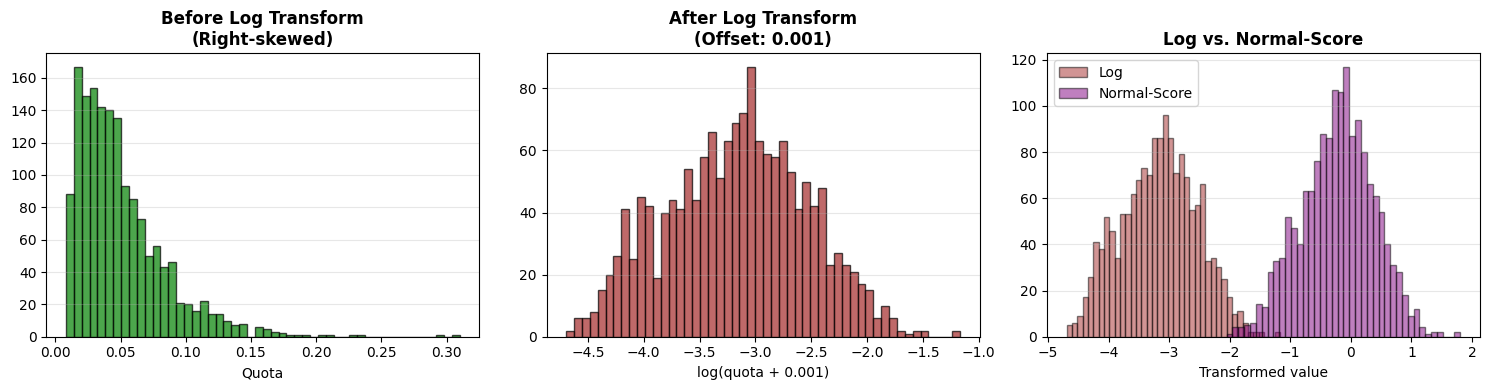

LogTransform: z = log(q + 0.001)
  Skewness: 1.840 → -0.000
  (NST skewness: -0.117 — closer to 0)


In [8]:
day_log = log_t.apply(day_det)

log_scores = day_log.loc[day_log["rain_indicator"] == 1, "precip_log"].values

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(quota, bins=50, color="green", edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Quota")
axes[0].set_title("Before Log Transform\n(Right-skewed)", fontweight="bold")
axes[0].grid(alpha=0.3, axis="y")

axes[1].hist(log_scores, bins=50, color="brown", edgecolor="black", alpha=0.7)
axes[1].set_xlabel(f"log(quota + {cfg.log_transform_offset})")
axes[1].set_title(f"After Log Transform\n(Offset: {cfg.log_transform_offset})", fontweight="bold")
axes[1].grid(alpha=0.3, axis="y")

axes[2].hist(log_scores, bins=40, color="brown", alpha=0.5, label="Log", edgecolor="black")
axes[2].hist(nst_scores, bins=40, color="purple", alpha=0.5, label="Normal-Score", edgecolor="black")
axes[2].set_xlabel("Transformed value")
axes[2].set_title("Log vs. Normal-Score", fontweight="bold")
axes[2].legend()
axes[2].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print(f"LogTransform: z = log(q + {cfg.log_transform_offset})")
print(f"  Skewness: {skew(quota):.3f} → {skew(log_scores):.3f}")
print(f"  (NST skewness: {skew(nst_scores):.3f} — closer to 0)")

## Summary: All Pipeline Stages

Visual comparison of distributions at each transformation stage.

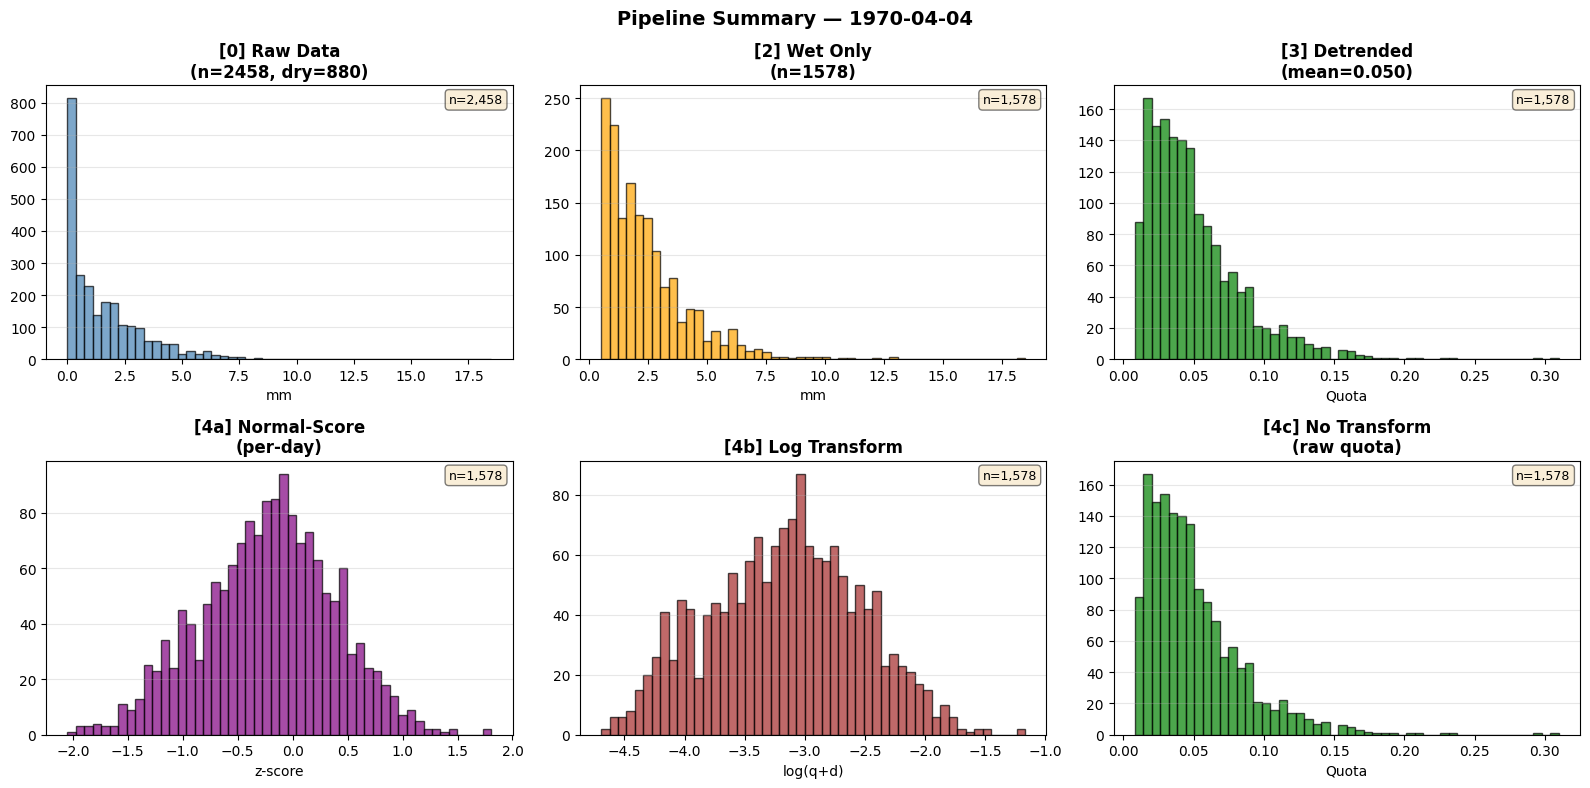

Stage                    Skewness       Mean        Std
-------------------------------------------------------
[0] Raw (all)               1.946      1.583      1.812
[2] Wet only                1.978      2.407      1.792
[3] Quota                   1.840      0.050      0.034
[4a] NST                   -0.117     -0.225      0.605
[4b] Log                   -0.000     -3.167      0.630


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

n_dry_count = int((rain_indicator == 0).sum())
data_stages = [
    (precip_mm,   "steelblue", f"[0] Raw Data\n(n={n_total}, dry={n_dry_count})", "mm"),
    (wet_precip,  "orange",    f"[2] Wet Only\n(n={n_wet})",                       "mm"),
    (quota,       "green",     f"[3] Detrended\n(mean={quota.mean():.3f})",        "Quota"),
    (nst_scores,  "purple",    f"[4a] Normal-Score\n(per-day)",                    "z-score"),
    (log_scores,  "brown",     f"[4b] Log Transform",                              "log(q+d)"),
    (quota,       "green",     f"[4c] No Transform\n(raw quota)",                  "Quota"),
]

for ax, (data, color, title, xlabel) in zip(axes.ravel(), data_stages):
    ax.hist(data, bins=50, color=color, alpha=0.7, edgecolor="black")
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontweight="bold")
    ax.grid(alpha=0.3, axis="y")
    ax.text(0.98, 0.97, f"n={len(data):,}", transform=ax.transAxes,
            ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.suptitle(f"Pipeline Summary — {DATE}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"{'Stage':<22} {'Skewness':>10} {'Mean':>10} {'Std':>10}")
print("-" * 55)
for name, data in [("[0] Raw (all)", precip_mm), ("[2] Wet only", wet_precip),
                    ("[3] Quota", quota), ("[4a] NST", nst_scores),
                    ("[4b] Log", log_scores)]:
    print(f"{name:<22} {skew(data):>10.3f} {data.mean():>10.3f} {data.std():>10.3f}")

## Which Transform to Use?

**LOO-CV Results** (from `results/cross_validation/cv_results.pkl`):

| Transform | Variogram | CRPS (mm) | MAE (mm) |
|-----------|-----------|-----------|----------|
| **none** | exponential | **0.7981** | **0.944** |
| normal_score | exponential | 0.8538 | 1.006 |
| log | exponential | 0.8573 | 1.003 |

### Interpretation

1. **No transform** gives best CRPS — kriging works well on detrended quotas directly
2. **Normal-score** is theoretically sound (Gaussian marginals) but slightly worse in practice
3. **Log** reduces skew but inflates uncertainty in the tails

**Production choice**: `transform='none'` + `variogram='exponential'`